In [1]:
###!pip install -q transformers datasets pandas

# ДЗ 4

По мотивам HiProbe-VAD [arXiv:2507.17394](https://arxiv.org/abs/2507.17394): самые дискриминативные признаки в LLM лежат в промежуточных слоях, а не в финальном. Метод DLSP выбирает лучший слой без обучения потом учит logreg на замороженных представлениях. Взял Qwen2.5-0.5B, замораживаю, считаю DLSP-метрики KL/LDR/Entropy,  учу logreg на каждом слое и сверяю выбор DLSP с лучшим слоем.

## Конфиг

Qwen2.5-0.5B: 24 блока, 25 hidden states, hidden_size 896, 0.5B параметров.

In [2]:
import random
import numpy as np
import torch

MODEL_ID = "Qwen/Qwen2.5-0.5B"
SEED = 42
EPS = 1e-6

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device == "cuda" else torch.float32
print("Device:", device, "| dtype:", dtype)

Device: mps | dtype: torch.float32


## IMDB

In [3]:
from datasets import load_dataset

raw = load_dataset("stanfordnlp/imdb")

def stratified_sample(split, n):
    texts, labels = split["text"], split["label"]
    by_class = {0: [], 1: []}
    for t, y in zip(texts, labels):
        by_class[y].append(t)
    rng = random.Random(SEED)
    out_t, out_y = [], []
    per = n // 2
    for y in (0, 1):
        pool = by_class[y]
        rng.shuffle(pool)
        out_t.extend(pool[:per])
        out_y.extend([y] * per)
    idx = list(range(len(out_t)))
    rng.shuffle(idx)
    return [out_t[i] for i in idx], np.array([out_y[i] for i in idx])

train_texts, y_train = stratified_sample(raw["train"], 2000)
test_texts, y_test = stratified_sample(raw["test"], 800)

print("train:", len(train_texts), "| баланс:", np.bincount(y_train))
print("test: ", len(test_texts), "| баланс:", np.bincount(y_test))

train: 2000 | баланс: [1000 1000]
test:  800 | баланс: [400 400]


## Извлечение представлений по слоям

Замороженная модель с `output_hidden_states=True`, прогоняем батчами за один forward. По каждому из 25 слоёв усредняем токены по маске, приводим к float32, кешируем `features_by_layer`.

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    output_hidden_states=True,
    attn_implementation="sdpa",
).to(device).eval()

num_layers = model.config.num_hidden_layers + 1
hidden_size = model.config.hidden_size
print("num_layers :", num_layers, "| hidden_size:", hidden_size)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

num_layers : 25 | hidden_size: 896


In [5]:
from tqdm import tqdm


@torch.no_grad()
def extract_features(texts, desc="extract"):
    layer_chunks = [[] for _ in range(num_layers)]
    for start in tqdm(range(0, len(texts), 16), desc=desc):
        batch = texts[start:start + 16]
        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=256,
        ).to(device)
        out = model(**enc)
        mask = enc["attention_mask"].unsqueeze(-1).to(dtype)
        denom = mask.sum(dim=1).clamp(min=1.0)
        for l, h in enumerate(out.hidden_states):
            pooled = (h * mask).sum(dim=1) / denom
            layer_chunks[l].append(pooled.float().cpu().numpy())
    return {l: np.concatenate(layer_chunks[l], axis=0) for l in range(num_layers)}

train_feats = extract_features(train_texts, "train")
test_feats = extract_features(test_texts, "test")
print("layers:", len(train_feats), "| shape 0:", train_feats[0].shape)

test: 100%|██████████| 50/50 [03:45<00:00,  4.50s/it]

layers: 25 | shape 0: (2000, 896)


## DLSP: информативность слоёв без обучения

Три метрики разделимости классов N и A по диагональной гауссиане, усредняю по измерениям:

In [6]:
def class_stats(X, y):
    Xn, Xa = X[y == 0], X[y == 1]
    mu_n, var_n = Xn.mean(0), Xn.var(0) + EPS
    mu_a, var_a = Xa.mean(0), Xa.var(0) + EPS
    return mu_n, var_n, mu_a, var_a

def kl_divergence_layer(X, y):
    mu_n, var_n, mu_a, var_a = class_stats(X, y)
    kl = 0.5 * (np.log(var_a / var_n) + (var_n + (mu_n - mu_a) ** 2) / var_a - 1.0)
    return float(kl.mean())

def ldr_layer(X, y):
    mu_n, var_n, mu_a, var_a = class_stats(X, y)
    ldr = (mu_n - mu_a) ** 2 / (var_n + var_a + EPS)
    return float(ldr.mean())

def entropy_layer(X):
    B = 20
    ent = np.empty(X.shape[1])
    for d in range(X.shape[1]):
        counts, _ = np.histogram(X[:, d], bins=B)
        p = counts / counts.sum()
        p = p[p > 0]
        ent[d] = -(p * np.log2(p)).sum()
    return float(ent.mean())

In [7]:
from scipy.stats import zscore

layers = list(range(num_layers))
kl_vals = np.array([kl_divergence_layer(train_feats[l], y_train) for l in layers])
ldr_vals = np.array([ldr_layer(train_feats[l], y_train) for l in layers])
ent_vals = np.array([entropy_layer(train_feats[l]) for l in layers])

z_kl, z_ldr, z_ent = zscore(kl_vals), zscore(ldr_vals), zscore(ent_vals)
saliency = z_kl + z_ldr + z_ent

l_star = int(np.argmax(saliency))
top3 = sorted(np.argsort(saliency)[-3:].tolist())
print("l*=", l_star)
print("top3:", top3)

l*= 13
top3: [13, 14, 16]


## Probing каждого слоя

На каждом слое учу `StandardScaler + LogisticRegression(lbfgs, max_iter=1000)`, замеряю Accuracy, F1, ROC-AUC.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

acc, f1, auc = [], [], []
for l in layers:
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf.fit(train_feats[l], y_train)
    proba = clf.predict_proba(test_feats[l])[:, 1]
    pred = (proba >= 0.5).astype(int)
    acc.append(accuracy_score(y_test, pred))
    f1.append(f1_score(y_test, pred))
    auc.append(roc_auc_score(y_test, proba))

results = pd.DataFrame({
    "layer": layers,
    "KL": kl_vals, "LDR": ldr_vals, "Entropy": ent_vals,
    "S": saliency,
    "accuracy": acc, "f1": f1, "roc_auc": auc,
})
best_probe = int(results["roc_auc"].idxmax())
print("best ROC-AUC layer:", best_probe)
results.round(4)

best ROC-AUC layer: 14


,layer,KL,LDR,Entropy,S,accuracy,f1,roc_auc
0,0,0.0093,0.0041,2.8037,-6.0869,0.7262,0.7245,0.8115
1,1,0.0259,0.0165,2.8938,-3.8495,0.7500,0.7468,0.8267
2,2,0.0243,0.0168,2.9682,-3.5568,0.7275,0.7241,0.8178
3,3,0.0222,0.0134,2.8134,-4.6635,0.7300,0.7300,0.7971
4,4,0.0350,0.0192,2.6376,-4.3807,0.7625,0.7595,0.8545
5,5,0.0354,0.0273,2.9935,-2.1066,0.7975,0.7995,0.8742
6,6,0.0345,0.0247,3.1191,-1.6929,0.7825,0.7809,0.8646
7,7,0.0358,0.0274,3.0916,-1.5840,0.7938,0.7925,0.8695
8,8,0.0365,0.0301,3.1020,-1.3311,0.8075,0.8051,0.8955
9,9,0.0331,0.0272,3.1311,-1.5733,0.8088,0.8056,0.8900


## Графики

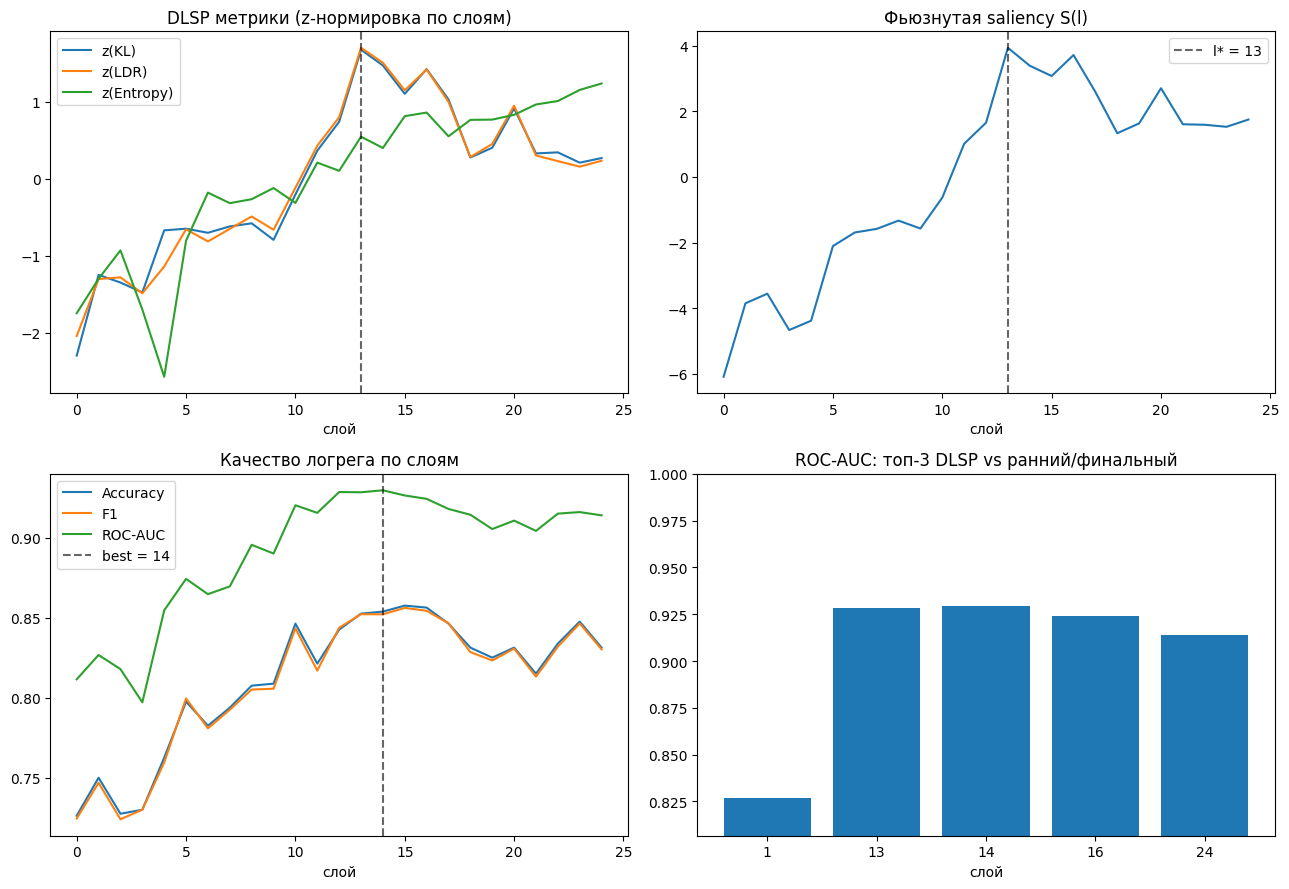

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(layers, z_kl, label="z(KL)")
ax[0, 0].plot(layers, z_ldr, label="z(LDR)")
ax[0, 0].plot(layers, z_ent, label="z(Entropy)")
ax[0, 0].axvline(l_star, color="k", ls="--", alpha=0.6)
ax[0, 0].set_title("DLSP метрики (z-нормировка по слоям)")
ax[0, 0].set_xlabel("слой"); ax[0, 0].legend()

ax[0, 1].plot(layers, saliency)
ax[0, 1].axvline(l_star, color="k", ls="--", alpha=0.6, label=f"l* = {l_star}")
ax[0, 1].set_title("Фьюзнутая saliency S(l)")
ax[0, 1].set_xlabel("слой"); ax[0, 1].legend()

ax[1, 0].plot(layers, acc, label="Accuracy")
ax[1, 0].plot(layers, f1, label="F1")
ax[1, 0].plot(layers, auc, label="ROC-AUC")
ax[1, 0].axvline(best_probe, color="k", ls="--", alpha=0.6, label=f"best = {best_probe}")
ax[1, 0].set_title("Качество логрега по слоям")
ax[1, 0].set_xlabel("слой"); ax[1, 0].legend()

bar_layers = sorted(set(top3) | {1, num_layers - 1})
bar_auc = [results.loc[l, "roc_auc"] for l in bar_layers]
ax[1, 1].bar([str(l) for l in bar_layers], bar_auc)
ax[1, 1].set_ylim(min(bar_auc) - 0.02, 1.0)
ax[1, 1].set_title("ROC-AUC: топ-3 DLSP vs ранний/финальный")
ax[1, 1].set_xlabel("слой")

plt.tight_layout()
plt.show()

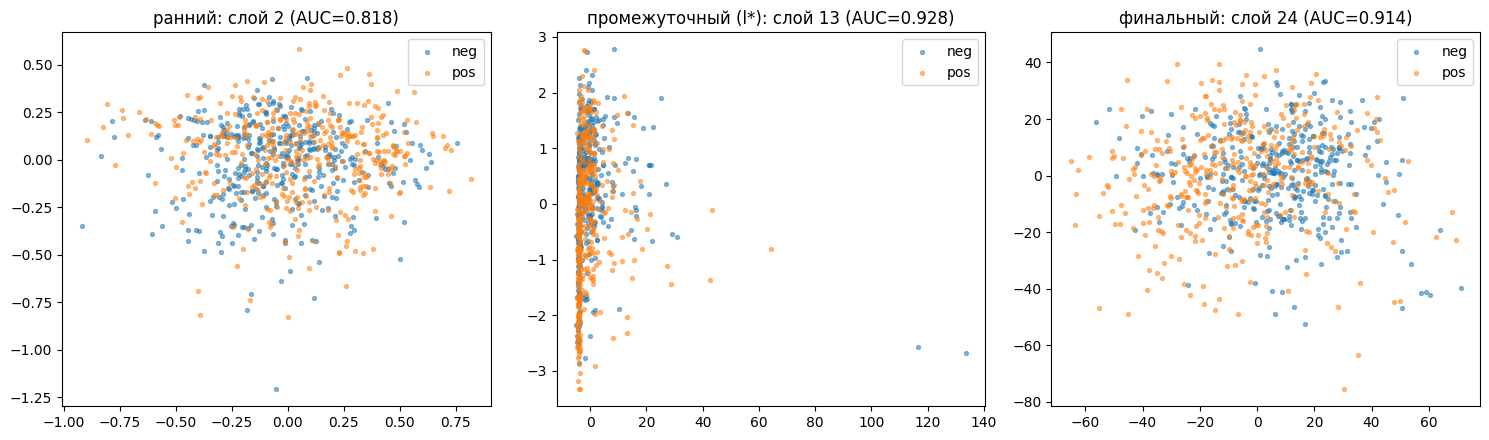

In [10]:
from sklearn.decomposition import PCA

early = 2
middle = l_star
final = num_layers - 1
panels = [("ранний", early), ("промежуточный (l*)", middle), ("финальный", final)]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, (name, l) in zip(ax, panels):
    emb = PCA(n_components=2).fit_transform(test_feats[l])
    for cls, lab in [(0, "neg"), (1, "pos")]:
        m = y_test == cls
        a.scatter(emb[m, 0], emb[m, 1], s=8, alpha=0.5, label=lab)
    a.set_title(f"{name}: слой {l} (AUC={results.loc[l, 'roc_auc']:.3f})")
    a.legend()
plt.tight_layout()
plt.show()

## Сравнение третей слоёв

Делю на трети, усредняю probing, сверяю лучший слой с выбором DLSP.

In [11]:
q1, q2 = num_layers // 3, 2 * num_layers // 3
groups = {
    "начальные": results[results.layer < q1],
    "промежуточные": results[(results.layer >= q1) & (results.layer < q2)],
    "финальные": results[results.layer >= q2],
}
summary = pd.DataFrame({
    name: [g["accuracy"].mean(), g["f1"].mean(), g["roc_auc"].mean(), g["S"].mean()]
    for name, g in groups.items()
}, index=["accuracy", "f1", "roc_auc", "S"]).T
print(summary.round(4))
print()
print(f"DLSP l* = {l_star}, эмпирически лучший по AUC = {best_probe}, |разница| = {abs(l_star - best_probe)} слоёв")
print(f"оба в промежуточной зоне [{q1}, {q2}): "
      f"{q1 <= l_star < q2 and q1 <= best_probe < q2}")

               accuracy      f1  roc_auc       S
начальные        0.7588  0.7572   0.8395 -3.4901
промежуточные    0.8362  0.8344   0.9167  1.1885
финальные        0.8353  0.8338   0.9135  2.0459

DLSP l* = 13, эмпирически лучший по AUC = 14, |разница| = 1 слоёв
оба в промежуточной зоне [8, 16): True


## Scorers на топ-3 слоях

logreg scorers на трёх лучших по saliency слоях с тестовыми метриками.

In [12]:
scorer_rows = []
for l in top3:
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf.fit(train_feats[l], y_train)
    proba = clf.predict_proba(test_feats[l])[:, 1]
    pred = (proba >= 0.5).astype(int)
    scorer_rows.append({
        "layer": l,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    })
pd.DataFrame(scorer_rows).round(4)

,layer,accuracy,f1,roc_auc
0,13,0.8525,0.8521,0.9283
1,14,0.8538,0.8521,0.9295
2,16,0.8562,0.8542,0.9242


## Выводы

Per-layer probing Qwen2.5-0.5B на IMDB, 2000 train / 800 test, 25 слоёв, mean-pooling по маске.

| зона | acc | AUC |
|---|---|---|
| начальные | 0.7588 | 0.8395 |
| промежуточные | 0.8362 | 0.9167 |
| финальные | 0.8353 | 0.9135 |

Лучшая зона промежуточная, а не выход модели. DLSP без обучения выбрал слой почти  не хуже эмпирически лучшего по AUC.